# Chapter 14: Ensemble Methods Assessment

## Assignment Overview

**Business Context**: You're a data analyst working for a financial services company. Your manager wants you to build **ensemble classification models** to predict whether credit card transactions are fraudulent. This is a **binary classification** task where you need to classify transactions as either "Fraud" (1) or "No Fraud" (0) based on transaction characteristics, customer demographics, and merchant information.

**Learning Objectives**:
- Understand how ensemble methods combine multiple models to improve predictions
- Build and evaluate bagging classifiers
- Build and evaluate random forest classifiers
- Build and evaluate boosting classifiers (AdaBoost, Gradient Boosting, XGBoost)
- Build and evaluate stacking classifiers
- Compare ensemble methods to single baseline models
- Interpret feature importance from ensemble models
- Understand when to use different ensemble methods

**Important Notes**:
- This assignment focuses on **Chapter 14 content only** (ensemble methods)
- You **WILL** split data into train/test sets (essential for evaluation)
- The goal is **predictive classification accuracy** and **probability quality** (log loss)
- Use sklearn pipelines to prevent data leakage
- Use `random_state=27` for all models that accept it (for reproducibility)

---

## Dataset Information

**Source**: Credit Card Fraud Detection Dataset  
**Description**:  
This dataset contains information about credit card transactions, including transaction details, customer demographics, merchant information, and whether each transaction was fraudulent. The dataset includes a mix of numeric and categorical features that can be used to predict fraud.

**Target Variable**: `Fraud` - binary variable indicating whether the transaction was fraudulent (1) or not (0)

**Data Dictionary** (Key Variables):
- **Transaction ID**: Unique identifier for each transaction (drop this - not a feature)
- **Date**: Transaction date
- **Day of Week**: Day of the week the transaction occurred
- **Time**: Hour of day (0-23)
- **Type of Card**: Card type (Visa, MasterCard, etc.)
- **Entry Mode**: How the card was used (Tap, PIN, CVC)
- **Amount**: Transaction amount
- **Type of Transaction**: Transaction type (POS, Online, ATM)
- **Merchant Group**: Category of merchant (Entertainment, Services, Restaurant, etc.)
- **Country of Transaction**: Country where transaction occurred
- **Shipping Address**: Shipping address country
- **Country of Residence**: Customer's country of residence
- **Gender**: Customer gender (M, F)
- **Age**: Customer age
- **Bank**: Bank name
- **Fraud**: Binary target variable (1 = Fraud, 0 = No Fraud)

**Note**: This dataset contains a mix of numeric and categorical features. Some features may have missing values that need to be handled. The dataset has moderate class imbalance (approximately 7% fraud), which makes precision and recall important metrics.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform data preprocessing for ensemble classification modeling.

## Question 1: Load and Explore the Dataset

Load the `CreditCardData.csv` file and perform initial exploration:
1. Load the dataset into a Pandas DataFrame
2. Display the dataset shape and first few rows
3. Check the distribution of the target variable `Fraud`
4. Display the value counts for the `Fraud` column
5. Calculate and display the percentage of fraudulent transactions

**Checkpoint Question**: What percentage of transactions are fraudulent (Fraud=1)? Round to 2 decimal places (e.g., enter 32.69 not 0.3269 or 32.69%).

In [10]:
# Question 1: Load and explore the dataset
import pandas as pd
from pathlib import Path

# Try local notebook folder first, then workspace-relative path.
candidate_paths = [Path("CreditCardData.csv"), Path("Chapter-14/CreditCardData.csv")]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find CreditCardData.csv")

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nFraud distribution (normalized):")
print(df["Fraud"].value_counts(normalize=True).sort_index())

print("\nFraud value counts:")
print(df["Fraud"].value_counts().sort_index())

fraud_pct = df["Fraud"].mean() * 100
print(f"\nPercentage of fraudulent transactions: {fraud_pct:.2f}")

Dataset shape: (100000, 16)

First 5 rows:
  Transaction ID       Date Day of Week  Time Type of Card Entry Mode  Amount  \
0      #3577 209  14-Oct-20   Wednesday    19         Visa        Tap     5.0   
1      #3039 221  14-Oct-20   Wednesday    17   MasterCard        PIN   288.0   
2      #2694 780  14-Oct-20   Wednesday    14         Visa        Tap     5.0   
3      #2640 960  13-Oct-20     Tuesday    14         Visa        Tap    28.0   
4      #2771 031  13-Oct-20     Tuesday    23         Visa        CVC    91.0   

  Type of Transaction Merchant Group Country of Transaction Shipping Address  \
0                 POS  Entertainment         United Kingdom   United Kingdom   
1                 POS       Services                    USA              USA   
2                 POS     Restaurant                  India            India   
3                 POS  Entertainment         United Kingdom            India   
4              Online    Electronics                    USA           

## Question 2: Data Preprocessing

Prepare the data for modeling:
1. Drop the `Transaction ID` column (this is an identifier, not a feature)
2. Separate features (X) and target (y)
3. Check for missing values and handle them appropriately
4. Identify numeric and categorical columns
5. Create a preprocessing pipeline using `ColumnTransformer`:
   - For numeric features: Use `SimpleImputer` with median strategy, then `StandardScaler`
   - For categorical features: Use `SimpleImputer` with most_frequent strategy, then `OneHotEncoder`
6. Create train/test split (80/20, stratified by target, random_state=27)
7. Display the shapes of training and testing sets

**Checkpoint Question**: How many samples are in the training set?

In [2]:
# Question 2: Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Drop identifier column and split features/target
df_model = df.drop(columns=["Transaction ID"]).copy()
X = df_model.drop(columns=["Fraud"])
y = df_model["Fraud"]

# Missing values overview
missing_counts = X.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("Missing values by column (non-zero only):")
print(missing_counts if not missing_counts.empty else "No missing values found in X.")

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"\nNumeric feature count: {len(numeric_features)}")
print(f"Categorical feature count: {len(categorical_features)}")

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=27
)

print("\nTrain/Test shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print(f"\nTraining set sample count: {len(X_train)}")

Missing values by column (non-zero only):
Merchant Group      10
Amount               6
Shipping Address     5
Gender               4
dtype: int64

Numeric feature count: 3
Categorical feature count: 11

Train/Test shapes:
X_train: (80000, 14)
X_test:  (20000, 14)
y_train: (80000,)
y_test:  (20000,)

Training set sample count: 80000


# Part 2: Baseline Models

In this section, you'll build single baseline models to compare against ensemble methods.

## Question 3: Single Decision Tree Baseline

Build a single decision tree classifier as a baseline:
1. Create a pipeline with preprocessing and DecisionTreeClassifier
2. Use `max_depth=3` and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss
   - Confusion matrix

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [3]:
# Question 3: Single decision tree baseline
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=3, random_state=27)),
])

decision_tree_model.fit(X_train, y_train)

tree_predictions = decision_tree_model.predict(X_test)
tree_probabilities = decision_tree_model.predict_proba(X_test)

tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_log_loss = log_loss(y_test, tree_probabilities)
tree_confusion_matrix = confusion_matrix(y_test, tree_predictions)

print(f"Decision tree test accuracy: {tree_accuracy:.4f}")
print(f"Decision tree test log loss: {tree_log_loss:.4f}")
print("Decision tree confusion matrix:")
print(tree_confusion_matrix)


Decision tree test accuracy: 0.9631
Decision tree test log loss: 0.0787
Decision tree confusion matrix:
[[18561     0]
 [  737   702]]


## Question 4: Logistic Regression Baseline

Build a logistic regression classifier as a baseline:
1. Create a pipeline with preprocessing and LogisticRegression
2. Use `max_iter=2000` and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [4]:
# Question 4: Logistic regression baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=27)),
])

logistic_regression_model.fit(X_train, y_train)

logistic_predictions = logistic_regression_model.predict(X_test)
logistic_probabilities = logistic_regression_model.predict_proba(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_log_loss = log_loss(y_test, logistic_probabilities)

print(f"Logistic regression test accuracy: {logistic_accuracy:.4f}")
print(f"Logistic regression test log loss: {logistic_log_loss:.4f}")


Logistic regression test accuracy: 0.9717
Logistic regression test log loss: 0.0768


# Part 3: Bagging

In this section, you'll build a bagging ensemble classifier.

## Question 5: Bagging Classifier

Build a bagging classifier:
1. Create a pipeline with preprocessing and BaggingClassifier
2. Use DecisionTreeClassifier as base estimator with `max_depth=3`
3. Set `n_estimators=100` and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [5]:
# Question 5: Bagging classifier
from sklearn.ensemble import BaggingClassifier

bagging_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=27),
            n_estimators=100,
            random_state=27,
        ),
    ),
])

bagging_model.fit(X_train, y_train)

bagging_predictions = bagging_model.predict(X_test)
bagging_probabilities = bagging_model.predict_proba(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_predictions)
bagging_log_loss = log_loss(y_test, bagging_probabilities)

print(f"Bagging test accuracy: {bagging_accuracy:.4f}")
print(f"Bagging test log loss: {bagging_log_loss:.4f}")


Bagging test accuracy: 0.9631
Bagging test log loss: 0.0786


# Part 4: Random Forests

In this section, you'll build a random forest classifier and analyze feature importance.

## Question 6: Random Forest Classifier

Build a random forest classifier:
1. Create a pipeline with preprocessing and RandomForestClassifier
2. Use `n_estimators=100`, `max_depth=None`, `min_samples_leaf=5`, `random_state=27`, `n_jobs=-1`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss
   - Test ROC AUC

**Checkpoint Question**: What is the test ROC AUC? Round your answer to 4 decimal places.

In [6]:
# Question 6: Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_leaf=5,
            random_state=27,
            n_jobs=-1,
        ),
    ),
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_log_loss = log_loss(y_test, rf_probabilities)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities[:, 1])

print(f"Random forest test accuracy: {rf_accuracy:.4f}")
print(f"Random forest test log loss: {rf_log_loss:.4f}")
print(f"Random forest test ROC AUC: {rf_roc_auc:.4f}")


Random forest test accuracy: 0.9849
Random forest test log loss: 0.0535
Random forest test ROC AUC: 0.9929


## Question 7: Feature Importance

Analyze feature importance from the random forest:
1. Extract feature importances from the trained random forest model
2. Get feature names from the preprocessing pipeline (after one-hot encoding)
3. Create a DataFrame with feature names and importance scores
4. Sort by importance (descending)
5. Display the top 10 most important features
6. Create a bar plot of the top 10 feature importances

**Checkpoint Question**: What is the name of the most important feature?

                                       feature  importance
0                                    num__Time    0.365241
43    cat__Country of Residence_United Kingdom    0.127952
33  cat__Country of Transaction_United Kingdom    0.074793
1                                  num__Amount    0.066695
38        cat__Shipping Address_United Kingdom    0.049967
40             cat__Country of Residence_India    0.023126
39             cat__Country of Residence_China    0.021813
42               cat__Country of Residence_USA    0.021683
41            cat__Country of Residence_Russia    0.021615
32             cat__Country of Transaction_USA    0.018527


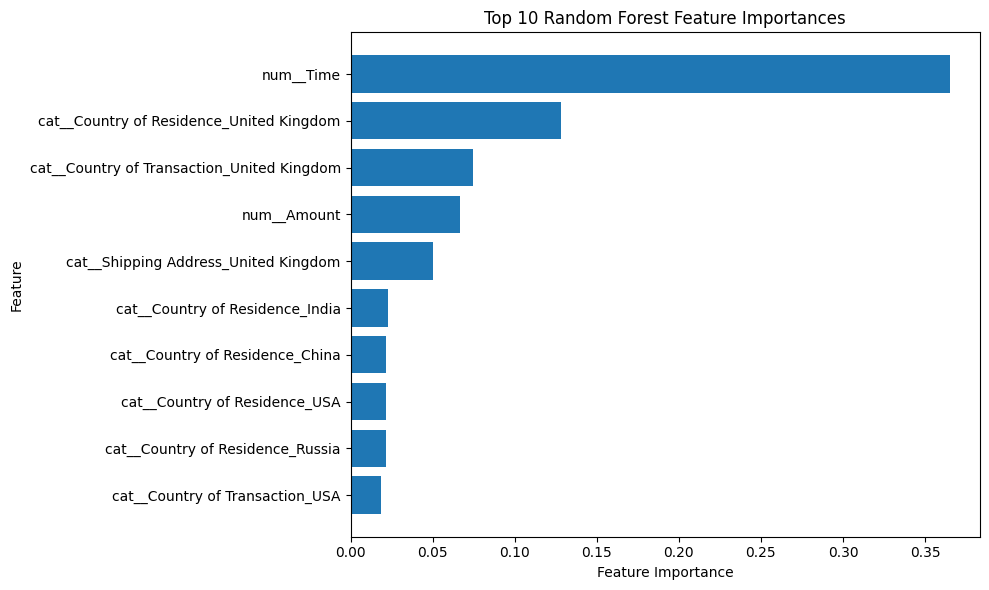

In [7]:
# Question 7: Feature importance
import matplotlib.pyplot as plt

rf_feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = random_forest_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False)

top_10_features = feature_importance_df.head(10)
print(top_10_features)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"][::-1], top_10_features["importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


# Part 5: AdaBoost

In this section, you'll build an AdaBoost classifier.

## Question 8: AdaBoost Classifier

Build an AdaBoost classifier:
1. Create a pipeline with preprocessing and AdaBoostClassifier
2. Use DecisionTreeClassifier as base estimator with `max_depth=1` (decision stumps)
3. Set `n_estimators=100`, `learning_rate=1.0`, and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? Round your answer to 4 decimal places.

In [8]:
# Question 8: AdaBoost classifier
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=27),
            n_estimators=100,
            learning_rate=1.0,
            random_state=27,
        ),
    ),
])

adaboost_model.fit(X_train, y_train)

adaboost_predictions = adaboost_model.predict(X_test)
adaboost_probabilities = adaboost_model.predict_proba(X_test)

adaboost_accuracy = accuracy_score(y_test, adaboost_predictions)
adaboost_log_loss = log_loss(y_test, adaboost_probabilities)

print(f"AdaBoost test accuracy: {adaboost_accuracy:.4f}")
print(f"AdaBoost test log loss: {adaboost_log_loss:.4f}")


AdaBoost test accuracy: 0.9845
AdaBoost test log loss: 0.4192


# Part 6: Gradient Boosting

In this section, you'll build a gradient boosting classifier.

## Question 9: Gradient Boosting Classifier

Build a gradient boosting classifier:
1. Create a pipeline with preprocessing and GradientBoostingClassifier
2. Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, and `random_state=27`
3. Fit the model on training data
4. Make predictions on test set
5. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [9]:
# Question 9: Gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

# GradientBoostingClassifier requires dense input, so use dense one-hot encoding here.
gb_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", gb_categorical_transformer, categorical_features),
    ]
)

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", gb_preprocessor),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=27,
        ),
    ),
])

gradient_boosting_model.fit(X_train, y_train)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)
gradient_boosting_probabilities = gradient_boosting_model.predict_proba(X_test)

gradient_boosting_accuracy = accuracy_score(y_test, gradient_boosting_predictions)
gradient_boosting_log_loss = log_loss(y_test, gradient_boosting_probabilities)

print(f"Gradient boosting test accuracy: {gradient_boosting_accuracy:.4f}")
print(f"Gradient boosting test log loss: {gradient_boosting_log_loss:.4f}")


Gradient boosting test accuracy: 0.9846
Gradient boosting test log loss: 0.0467


# Part 7: XGBoost

In this section, you'll build an XGBoost classifier if it's available.

## Question 10: XGBoost Classifier

Build an XGBoost classifier:
1. Import XGBClassifier from xgboost
2. Create a pipeline with preprocessing and XGBClassifier
3. Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, and `random_state=27`
4. Fit the model on training data
5. Make predictions on test set
6. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test accuracy? (Round to 4 decimal places)

In [ ]:
# Question 10: XGBoost classifier


# Part 8: Stacking

In this section, you'll build a stacking classifier.

## Question 11: Stacking Classifier

Build a stacking classifier using the efficient pattern from Chapter 14:
1. Create a pipeline that includes:
   - The preprocessing step (same preprocessor used throughout)
   - A StackingClassifier with these base learners (no separate preprocessing needed):
     - LogisticRegression (max_iter=2000, random_state=27)
     - RandomForestClassifier (n_estimators=50, random_state=27)
     - KNeighborsClassifier (n_neighbors=15)
   - Final estimator: LogisticRegression()
   - Use `cv=5` for cross-validation and `n_jobs=-1`
2. Fit the model on training data
3. Make predictions on test set
4. Calculate and display:
   - Test accuracy
   - Test log loss

**Checkpoint Question**: What is the test log loss? Round your answer to 4 decimal places.

In [ ]:
# Question 11: Stacking classifier

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

stacking_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        StackingClassifier(
            estimators=[
                (
                    "lr",
                    LogisticRegression(max_iter=2000, random_state=27),
                ),
                (
                    "rf",
                    RandomForestClassifier(n_estimators=50, random_state=27),
                ),
                (
                    "knn", KNeighborsClassifier(n_neighbors=15)),
            ],
            final_estimator=LogisticRegression(),
            cv=5,
            n_jobs=-1,
        ),
    ),
])

stacking_model.fit(X_train, y_train)

stacking_predictions = stacking_model.predict(X_test)
stacking_probabilities = stacking_model.predict_proba(X_test)

stacking_accuracy = accuracy_score(y_test, stacking_predictions)
stacking_log_loss = log_loss(y_test, stacking_probabilities)

print(f"Stacking test accuracy: {stacking_accuracy:.4f}")
print(f"Stacking test log loss: {stacking_log_loss:.4f}")

# Part 9: Model Comparison

In this section, you'll compare all models and analyze their performance.

## Question 12: Create Comparison Table

Create a comprehensive comparison of all models:
1. Create a list/dictionary to store results for all models:
   - Decision Tree (baseline)
   - Logistic Regression (baseline)
   - Bagging
   - Random Forest
   - AdaBoost
   - Gradient Boosting
   - XGBoost (if available)
   - Stacking
2. For each model, extract:
   - Model name
   - Test accuracy
   - Test log loss
3. Create a DataFrame with columns: Model Name, Test Accuracy, Test Log Loss
4. Sort by log loss (ascending), then by accuracy (descending)
5. Display the formatted comparison table

**Checkpoint Question**: Which model has the lowest log loss? (Answer with the exact model name from your table which should match the model names provided above)

In [13]:
# Question 12: Create comparison table

import pandas as pd

# Store model metrics using exact names from the prompt.
model_results = [
    {
        "Model Name": "Decision Tree (baseline)",
        "Test Accuracy": tree_accuracy,
        "Test Log Loss": tree_log_loss,
    },
    {
        "Model Name": "Logistic Regression (baseline)",
        "Test Accuracy": logistic_accuracy,
        "Test Log Loss": logistic_log_loss,
    },
    {
        "Model Name": "Bagging",
        "Test Accuracy": bagging_accuracy,
        "Test Log Loss": bagging_log_loss,
    },
    {
        "Model Name": "Random Forest",
        "Test Accuracy": rf_accuracy,
        "Test Log Loss": rf_log_loss,
    },
    {
        "Model Name": "AdaBoost",
        "Test Accuracy": adaboost_accuracy,
        "Test Log Loss": adaboost_log_loss,
    },
    {
        "Model Name": "Gradient Boosting",
        "Test Accuracy": gradient_boosting_accuracy,
        "Test Log Loss": gradient_boosting_log_loss,
    },
]

# Include optional models only if they were built in prior questions.
if "xgboost_accuracy" in globals() and "xgboost_log_loss" in globals():
    model_results.append(
        {
            "Model Name": "XGBoost",
            "Test Accuracy": xgboost_accuracy,
            "Test Log Loss": xgboost_log_loss,
        }
    )

if "stacking_accuracy" in globals() and "stacking_log_loss" in globals():
    model_results.append(
        {
            "Model Name": "Stacking",
            "Test Accuracy": stacking_accuracy,
            "Test Log Loss": stacking_log_loss,
        }
    )

comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values(
    by=["Test Log Loss", "Test Accuracy"],
    ascending=[True, False]
).reset_index(drop=True)

comparison_df_display = comparison_df.copy()
comparison_df_display["Test Accuracy"] = comparison_df_display["Test Accuracy"].map(
    lambda x: f"{x:.4f}"
)
comparison_df_display["Test Log Loss"] = comparison_df_display["Test Log Loss"].map(
    lambda x: f"{x:.4f}"
)

print("Model comparison table (sorted by lowest log loss):")
display(comparison_df_display)

best_model_name = comparison_df.loc[0, "Model Name"]
best_model_log_loss = comparison_df.loc[0, "Test Log Loss"]
print(f"\nLowest log loss model: {best_model_name} ({best_model_log_loss:.4f})")

Model comparison table (sorted by lowest log loss):


,Model Name,Test Accuracy,Test Log Loss
0,Gradient Boosting,0.9846,0.0467
1,Random Forest,0.9849,0.0535
2,Logistic Regression (baseline),0.9717,0.0768
3,Bagging,0.9631,0.0786
4,Decision Tree (baseline),0.9631,0.0787
5,AdaBoost,0.9845,0.4192



Lowest log loss model: Gradient Boosting (0.0467)


## Question 13: Confusion Matrix Comparison

Compare confusion matrices for the top 2 models:
1. Identify the top 2 models based on log loss (from Question 12)
2. For each of the top 2 models:
   - Generate predictions on test set
   - Create confusion matrix
   - Plot confusion matrix as a heatmap
   - Calculate and display precision and recall for the fraud class (Fraud=1)
3. Compare the precision and recall values

**Checkpoint Question**: For the best model (lowest log loss), what is the recall for the fraud class (Fraud=1)? Round your answer to 4 decimal places.

Top 2 models by lowest test log loss:
          Model Name  Test Accuracy  Test Log Loss
0  Gradient Boosting         0.9846         0.0467
1      Random Forest         0.9848         0.0535


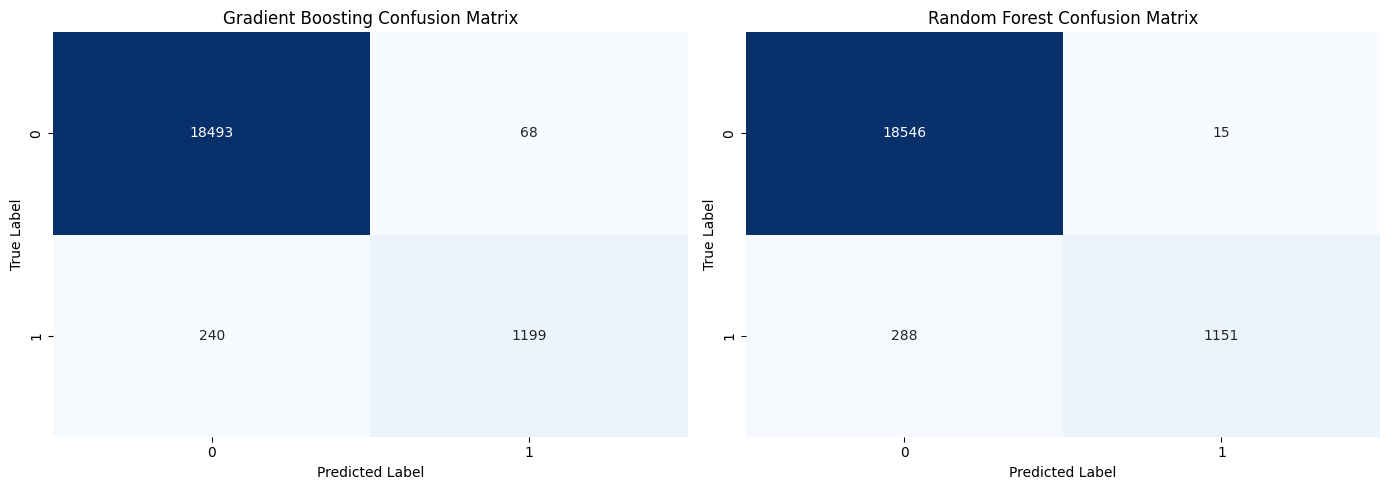


Precision/Recall comparison for Fraud=1:
          Model Name  Precision (Fraud=1)  Recall (Fraud=1)
0  Gradient Boosting               0.9463            0.8332
1      Random Forest               0.9871            0.7999

Checkpoint answer (best model recall for Fraud=1): 0.8332


In [11]:
# Question 13: Confusion matrix comparison
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, log_loss

# Collect all available trained models from earlier questions.
model_registry = []
candidate_models = [
    ("Decision Tree", "decision_tree_model"),
    ("Logistic Regression", "logistic_regression_model"),
    ("Bagging", "bagging_model"),
    ("Random Forest", "random_forest_model"),
    ("AdaBoost", "adaboost_model"),
    ("Gradient Boosting", "gradient_boosting_model"),
    ("XGBoost", "xgboost_model"),
    ("Stacking", "stacking_model"),
]

for model_name, var_name in candidate_models:
    if var_name in globals():
        model_registry.append((model_name, globals()[var_name]))

if len(model_registry) < 2:
    raise ValueError(
        "At least two trained models are required. Run previous model-building cells first."
    )

# Build a comparison table (Q12-style) from available models and pick top 2 by log loss.
comparison_rows = []
for model_name, model_obj in model_registry:
    probs = model_obj.predict_proba(X_test)
    preds = model_obj.predict(X_test)
    comparison_rows.append(
        {
            "Model Name": model_name,
            "Test Accuracy": (preds == y_test).mean(),
            "Test Log Loss": log_loss(y_test, probs),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["Test Log Loss", "Test Accuracy"], ascending=[True, False]
).reset_index(drop=True)

top_2 = comparison_df.head(2)
top_2_names = top_2["Model Name"].tolist()
name_to_model = {name: model for name, model in model_registry}

print("Top 2 models by lowest test log loss:")
print(top_2[["Model Name", "Test Accuracy", "Test Log Loss"]].round(4))

# Confusion matrix + precision/recall comparison for top 2 models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_rows = []

for idx, model_name in enumerate(top_2_names):
    model_obj = name_to_model[model_name]
    preds = model_obj.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
    )
    axes[idx].set_title(f"{model_name} Confusion Matrix")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    precision_fraud = precision_score(y_test, preds, pos_label=1, zero_division=0)
    recall_fraud = recall_score(y_test, preds, pos_label=1, zero_division=0)

    metrics_rows.append(
        {
            "Model Name": model_name,
            "Precision (Fraud=1)": precision_fraud,
            "Recall (Fraud=1)": recall_fraud,
        }
    )

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics_rows)
print("\nPrecision/Recall comparison for Fraud=1:")
print(metrics_df.round(4))

best_model_name = top_2_names[0]
best_model_recall = metrics_df.loc[
    metrics_df["Model Name"] == best_model_name, "Recall (Fraud=1)"
].iloc[0]

print(
    f"\nCheckpoint answer (best model recall for Fraud=1): {best_model_recall:.4f}"
)

# Summary and Reflection

Congratulations! You've completed the coding portion of the Chapter 14 ensemble methods assessment. You've learned how to:

1. Prepare data for ensemble classification modeling
2. Build baseline models (decision tree, logistic regression)
3. Build bagging classifiers
4. Build random forest classifiers and interpret feature importance
5. Build boosting classifiers (AdaBoost, Gradient Boosting, XGBoost)
6. Build stacking classifiers
7. Compare ensemble methods to single models
8. Evaluate models using accuracy, log loss, and confusion matrices

**Important Reminders**:
- **Ensemble methods** combine multiple models to improve predictions
- **Bagging** reduces variance by averaging many models trained on bootstrap samples
- **Random Forests** add feature randomness to bagging for better decorrelation
- **Boosting** reduces both bias and variance by sequentially correcting errors
- **Stacking** uses a meta-learner to combine diverse base models
- **Log loss** measures probability quality, which is important for threshold-based decisions
- **Feature importance** helps identify which features drive predictions

---

